# 06 — MRD Estimation Across Subsampled Cell Counts (500, 1,000, 5,000 Cells)

This notebook evaluates Linear Optimal Transport (LOT) + PLS Regression performance across varying cell subsampling depths (**500**, **1,000**, and **5,000** cells per sample) using the Stage 2 Analytics dataset.

### Key Questions Investigated:
1. **Particle Count Sensitivity**: Does increasing particle count improve patient-level quantification, or is LOT geometric linearization robust and stable even with lower cell counts?
2. **Within-Cohort vs. Cross-Cohort Generalization**: How does blast calibration scale from within-cohort cross-validation (BLAST110, LAIP29) to cross-cohort domain transfer (BLAST110 $\to$ LAIP29)?
3. **Clinical MRD Decision Cutoffs**: How do diagnostic sensitivity and specificity at clinical action thresholds (0.1%, 1.0%, 5.0%) behave as cell count scales?

In [ ]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import pearsonr

# ----------------------------------------------------------------------
# 1. ROBUST DATASET PATH RESOLUTION & WORKING DIRECTORY PRECAUTION
# ----------------------------------------------------------------------
try:
    current_wd = os.getcwd()
except (FileNotFoundError, OSError):
    # Fallback if working directory was orphaned/deleted
    os.chdir('/Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/notebooks')

candidates = [
    Path('data/stage2/stage2_analytics.h5'),
    Path('../data/stage2/stage2_analytics.h5'),
    Path('/Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage2/stage2_analytics.h5')
]
STAGE2_PATH = next((p for p in candidates if p.exists() and p.is_file()), None)
if STAGE2_PATH is None:
    raise FileNotFoundError('Could not locate valid stage2_analytics.h5 file across candidate paths.')
print(f'Using Stage 2 Analytics Dataset: {STAGE2_PATH}')

# ----------------------------------------------------------------------
# 2. PIPELINE CONFIGURATION & HYPERPARAMETERS
# ----------------------------------------------------------------------
TUBE = 'P1'
LOT_EMBEDDING_NAME = 'patient0_emd2_map'
MARKER_VERSION = '12'
CELL_COUNTS = [500, 1000, 5000]
N_COMPONENTS = 10
N_REPEATS = 20
THRESHOLDS = [0.1, 1.0, 5.0]
EPS = 1e-8
RNG = np.random.RandomState(42)

try:
    OUTDIR = os.path.abspath("quant_all_cells")
    os.makedirs(OUTDIR, exist_ok=True)
except Exception:
    OUTDIR = os.path.join(os.getcwd(), "quant_all_cells")
    os.makedirs(OUTDIR, exist_ok=True)

# Styling
FIG_WIDTH = 13.5
FIG_HEIGHT = 16.0
FIG_DPI = 300
FONT_SIZES = {
    'suptitle': 15.0,
    'subtitle': 11.5,
    'axis_labels': 11.0,
    'legend': 9.5,
    'inset_text': 9.0,
    'ticks': 9.0,
}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.labelsize': FONT_SIZES['ticks'],
    'ytick.labelsize': FONT_SIZES['ticks'],
    'figure.dpi': 120,
})
COL = {
    'BLAST110': '#1f77b4',
    'LAIP29_blast': '#d62728',
    'LAIP29_laip': '#2ca02c',
    'cross': '#9467bd',
}
CAT_COL = {'TP': '#2ca02c', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#d62728'}
GROUP_MARKER = {'Dx': 'o', 'FU': '^'}

# ----------------------------------------------------------------------
# 3. EXTRACTION & STATISTICAL FUNCTIONS WITH ROBUST ERROR HANDLING
# ----------------------------------------------------------------------
def extract_stage2(h5_path=STAGE2_PATH, dataset='BLAST110', cell_count=1000, tube='P1', embedding_name='patient0_emd2_map', marker_version='12', target='blast'):
    if not Path(h5_path).exists():
        raise FileNotFoundError(f"HDF5 file missing at: {h5_path}")
    
    with h5py.File(h5_path, 'r') as h5:
        if dataset not in h5:
            raise KeyError(f"Dataset '{dataset}' not found in HDF5 file.")
        ds_grp = h5[dataset]
        str_cell_count = str(cell_count)
        if str_cell_count not in ds_grp:
            available_counts = list(ds_grp.keys())
            raise KeyError(f"Cell count '{cell_count}' not found under '{dataset}'. Available: {available_counts}")
        
        cell_grp = ds_grp[str_cell_count]
        if tube not in cell_grp:
            raise KeyError(f"Tube '{tube}' not found under '{dataset}/{cell_count}'. Available: {list(cell_grp.keys())}")
        
        tube_grp = cell_grp[tube]
        m1_raw = tube_grp['preprocess_1']['marker_subset'][:] if 'preprocess_1' in tube_grp and 'marker_subset' in tube_grp['preprocess_1'] else []
        m1 = [m.decode() if isinstance(m, bytes) else str(m) for m in m1_raw]
        
        if 'preprocess_2' in tube_grp and 'marker_subset' in tube_grp['preprocess_2']:
            m2_raw = tube_grp['preprocess_2']['marker_subset'][:]
            m2 = [m.decode() if isinstance(m, bytes) else str(m) for m in m2_raw]
        else:
            m2 = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD45 KO', 'CD117', 'CD33']
            
        lot_grp = tube_grp.get('lot_embeddings', None)
        if lot_grp is None:
            raise KeyError(f"Missing 'lot_embeddings' group for dataset {dataset}, cell_count {cell_count}, tube {tube}")
            
        is_7 = str(marker_version).strip() in ['7', '2', 'seven']
        prep_id = '2' if (is_7 and '2' in lot_grp) else ('1' if '1' in lot_grp else list(lot_grp.keys())[0])
        p_grp = lot_grp[prep_id]
        
        emb_node = p_grp[embedding_name] if embedding_name in p_grp else p_grp[list(p_grp.keys())[0]]
        if 'embeddings' not in emb_node or 'patient_ids' not in emb_node:
            raise KeyError(f"Embedding node missing 'embeddings' or 'patient_ids' datasets.")
            
        embs = emb_node['embeddings'][:]
        pids = [p.decode() if isinstance(p, bytes) else str(p) for p in emb_node['patient_ids'][:]]
        n_cells = int(cell_count)
        n_m1 = len(m1) if len(m1) > 0 else 10
        
        if is_7 and embs.shape[1] == n_cells * n_m1:
            indices = [m1.index(m) for m in m2 if m in m1]
            if len(indices) > 0:
                embs_3d = embs.reshape((len(embs), n_cells, n_m1), order='F')
                embs = embs_3d[:, :, indices].reshape((len(embs), -1), order='F')
                marker_names_used = [m1[i] for i in indices]
            else:
                marker_names_used = m1
        else:
            marker_names_used = m2 if (is_7 and len(m2) > 0) else m1
            
        raw_grp = tube_grp.get('raw', {})
        meta_grp = tube_grp.get('metadata', {})
        meta_pids = [p.decode() if isinstance(p, bytes) else str(p) for p in meta_grp.get('patient_ids', [])]
        meta_lbls = [l.decode() if isinstance(l, bytes) else str(l) for l in meta_grp.get('labels', [])]
        lbl_map = dict(zip(meta_pids, meta_lbls))
        
        X_list, Y_list, G_list = [], [], []
        target_key = 'Blast' if target.lower() == 'blast' else 'LAIP'
        
        for emb, pid in zip(embs, pids):
            if pid not in raw_grp or 'population_counts' not in raw_grp[pid]:
                continue
            pop_node = raw_grp[pid]['population_counts']
            pop = pop_node[:]
            pop_names = [n.decode() if isinstance(n, bytes) else str(n) for n in pop_node.attrs.get('population_names', [])]
            if target_key not in pop_names:
                continue
            t_idx = pop_names.index(target_key)
            wbc_idx = pop_names.index('WBC') if 'WBC' in pop_names else 0
            ratio = float(pop[t_idx, 3]) if pop.shape[1] >= 4 else float(100.0 * (pop[t_idx, 1] + EPS) / (pop[wbc_idx, 1] + EPS))
            lbl = lbl_map.get(pid, '')
            group = 'Dx' if ('Dx' in pid or 'Dx' in lbl) else ('FU' if ('FU' in pid or 'FU' in lbl) else 'NA')
            X_list.append(emb)
            Y_list.append(ratio)
            G_list.append(group)
            
        return np.array(X_list), np.array(Y_list), np.array(G_list), marker_names_used

def repeated_oos(X, y_log, n_repeats=N_REPEATS, n_comp=N_COMPONENTS, rng=RNG):
    n = X.shape[0]
    preds = np.zeros(n)
    counts = np.zeros(n)
    if n < 5:
        pls = PLSRegression(n_components=min(n_comp, max(1, n-1)))
        pls.fit(X, y_log)
        return pls.predict(X).ravel(), np.ones(n, dtype=bool)
        
    for rep in range(n_repeats):
        indices = rng.permutation(n)
        folds = np.array_split(indices, 5)
        for val_idx in folds:
            if len(val_idx) == 0:
                continue
            train_idx = np.setdiff1d(np.arange(n), val_idx)
            if len(train_idx) == 0:
                continue
            n_c = min(n_comp, len(train_idx), X.shape[1])
            n_c = max(1, n_c)
            pls = PLSRegression(n_components=n_c)
            try:
                pls.fit(X[train_idx], y_log[train_idx])
                pred = pls.predict(X[val_idx]).ravel()
                preds[val_idx] += pred
                counts[val_idx] += 1
            except Exception:
                continue
    seen = counts > 0
    if seen.sum() > 0:
        preds[seen] /= counts[seen]
    return preds, seen

def cross_predict(X_train, y_train_log, X_test, n_comp=N_COMPONENTS):
    n_c = min(n_comp, X_train.shape[0], X_train.shape[1])
    n_c = max(1, n_c)
    pls = PLSRegression(n_components=n_c)
    pls.fit(X_train, y_train_log)
    return pls.predict(X_test).ravel()

def find_optimal_threshold(y_true, y_pred, clinical_thr):
    y_binary = (y_true >= clinical_thr).astype(int)
    if len(np.unique(y_binary)) < 2:
        return {'thr': clinical_thr, 'sens': 1.0, 'spec': 1.0}
    cand = np.percentile(y_pred, np.linspace(5, 95, 100))
    best = {'thr': clinical_thr, 'sens': 0.0, 'spec': 0.0}
    best_j = -1
    for cthr in cand:
        pred_bin = (y_pred >= cthr).astype(int)
        tp = np.sum((y_binary == 1) & (pred_bin == 1))
        fn = np.sum((y_binary == 1) & (pred_bin == 0))
        tn = np.sum((y_binary == 0) & (pred_bin == 0))
        fp = np.sum((y_binary == 0) & (pred_bin == 1))
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        j = sens + spec - 1
        if j > best_j:
            best_j = j
            best = {'thr': cthr, 'sens': sens, 'spec': spec}
    return best

def metrics(y_true_log, y_pred_log):
    if len(y_true_log) < 2 or np.std(y_true_log) == 0 or np.std(y_pred_log) == 0:
        r = 0.0
    else:
        r, _ = pearsonr(y_true_log, y_pred_log)
    rmse = np.sqrt(np.mean((y_true_log - y_pred_log) ** 2)) if len(y_true_log) > 0 else 0.0
    return {'r': r, 'rmse': rmse}

# ----------------------------------------------------------------------
# 4. PLOTTING SUBROUTINES
# ----------------------------------------------------------------------
def _calib(ax, res, color, title, panel):
    xt, xp = res['y_true_log'], res['y_pred_log']
    if len(xt) == 0 or len(xp) == 0:
        return
    lo = min(xt.min(), xp.min()) - 0.2
    hi = max(xt.max(), xp.max()) + 0.2
    ax.scatter(xt, xp, alpha=0.75, s=35, edgecolors='k', linewidths=0.5, color=color, zorder=3)
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.1, zorder=2)
    ax.axvline(0.0, color='gray', ls=':', lw=1.0)
    ax.axhline(0.0, color='gray', ls=':', lw=1.0)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual log$_{10}$(ratio %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
    ax.set_ylabel('Predicted log$_{10}$(ratio %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
    ax.set_title(f'{panel}) {title}', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
    ax.text(0.04, 0.92, f'$r$={res["r"]:.3f}\nRMSE={res["rmse"]:.3f}', transform=ax.transAxes, fontsize=FONT_SIZES['inset_text'], fontweight='bold', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    ax.grid(True, ls='--', lw=0.5, alpha=0.6)

def _laip_decision_dxfu(ax, res, opt, thr, panel, n_dx, n_fu):
    xt, xp = res['y_true_log'], res['y_pred_log']
    groups = res['groups']
    if len(xt) == 0:
        return
    clin = np.log10(thr)
    opt_line = np.log10(opt['thr'] + EPS)
    lo = min(xt.min(), xp.min()) - 0.2
    hi = max(xt.max(), xp.max()) + 0.2
    pos_t = res['y_true'] >= thr
    pos_p = res['y_pred'] >= opt['thr']
    cat = np.where(pos_t & pos_p, 'TP', np.where(~pos_t & ~pos_p, 'TN', np.where(~pos_t & pos_p, 'FP', 'FN')))
    for g in ('Dx', 'FU'):
        for c in ('TP', 'TN', 'FP', 'FN'):
            mask = (groups == g) & (cat == c)
            if mask.sum():
                ax.scatter(xt[mask], xp[mask], s=55, c=CAT_COL[c], marker=GROUP_MARKER[g], edgecolors='k', linewidths=0.5, alpha=0.9, zorder=3)
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.0, zorder=2)
    ax.axvline(clin, color='gray', ls=':', lw=1.2)
    ax.axhline(opt_line, color='purple', ls='-.', lw=1.4)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual log$_{10}$(LAIP/WBC %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
    ax.set_ylabel('Predicted log$_{10}$(LAIP/WBC %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
    ax.set_title(f'{panel}) LAIP decision @ {thr:g}%', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
    ax.text(0.04, 0.96, f'Dx n={n_dx}  FU n={n_fu}\nopt cut={opt["thr"]:.2f}%\nse={opt["sens"]:.2f} sp={opt["spec"]:.2f}', transform=ax.transAxes, fontsize=FONT_SIZES['inset_text'], fontweight='bold', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    ax.grid(True, ls='--', lw=0.5, alpha=0.6)

def _legend_axis(fig):
    handles = [
        Line2D([0], [0], marker='o', color='w', label='Dx (diagnosis)', markerfacecolor='gray', markeredgecolor='k', markersize=9),
        Line2D([0], [0], marker='^', color='w', label='FU (follow-up)', markerfacecolor='gray', markeredgecolor='k', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='TP', markerfacecolor=CAT_COL['TP'], markeredgecolor='k', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='TN', markerfacecolor=CAT_COL['TN'], markeredgecolor='k', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='FP', markerfacecolor=CAT_COL['FP'], markeredgecolor='k', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='FN', markerfacecolor=CAT_COL['FN'], markeredgecolor='k', markersize=9),
        Line2D([0], [0], color='gray', ls=':', lw=1.6, label='clinical cutoff'),
        Line2D([0], [0], color='purple', ls='-.', lw=1.6, label='optimal cutoff'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=8, fontsize=FONT_SIZES['legend'], frameon=True, bbox_to_anchor=(0.5, 0.005))

print('Environment and helper functions initialized successfully.') 


Using Stage 2 Analytics Dataset: ../data/stage2/stage2_analytics.h5
Environment and helper functions initialized successfully.


In [17]:
# ----------------------------------------------------------------------
# EVALUATION ACROSS CELL COUNTS (500, 1000, 5000)
# ----------------------------------------------------------------------
all_results = {}
table_rows = []

for cc in CELL_COUNTS:
    print(f'\n=======================================================')
    print(f'Running LOT+PLS Pipeline for Cell Count = {cc} cells')
    print(f'=======================================================')
    
    Xb, Yb, Gb, mb = extract_stage2(dataset='BLAST110', tube=TUBE, cell_count=cc, embedding_name=LOT_EMBEDDING_NAME, marker_version=MARKER_VERSION, target='blast')
    Xlb, Ylb, Glb, mlb = extract_stage2(dataset='LAIP29', tube=TUBE, cell_count=cc, embedding_name=LOT_EMBEDDING_NAME, marker_version=MARKER_VERSION, target='blast')
    Xll, Yll, Gll, mll = extract_stage2(dataset='LAIP29', tube=TUBE, cell_count=cc, embedding_name=LOT_EMBEDDING_NAME, marker_version=MARKER_VERSION, target='laip')
    
    res = {}
    def run_within(name, X, Y, groups=None):
        ylog = np.log10(Y + EPS)
        pred_log, seen = repeated_oos(X, ylog)
        yt, yp = Y[seen], 10 ** pred_log[seen]
        m = metrics(np.log10(yt + EPS), pred_log[seen])
        res[name] = dict(
            y_true=yt, y_pred=yp,
            y_true_log=np.log10(yt + EPS), y_pred_log=pred_log[seen],
            groups=(groups[seen] if groups is not None else None),
            **m
        )
        print(f'  [{name}] r={m["r"]:.3f}, RMSE={m["rmse"]:.3f}')
        return m
        
    mb_m = run_within('BLAST110_blast', Xb, Yb)
    mlb_m = run_within('LAIP29_blast', Xlb, Ylb)
    mll_m = run_within('LAIP29_laip', Xll, Yll, groups=Gll)
    
    cp_log = cross_predict(Xb, np.log10(Yb + EPS), Xlb)
    cyt = Ylb; cyp = 10 ** cp_log
    cross_m = metrics(np.log10(cyt + EPS), cp_log)
    res['cross'] = dict(y_true=cyt, y_pred=cyp, y_true_log=np.log10(cyt + EPS), y_pred_log=cp_log, groups=None, **cross_m)
    print(f'  [cross] r={cross_m["r"]:.3f}, RMSE={cross_m["rmse"]:.3f}')
    
    all_results[cc] = res
    
    # Extract clinical decision thresholds for LAIP29
    laip = res['LAIP29_laip']
    opts = {thr: find_optimal_threshold(laip['y_true'], laip['y_pred'], thr) for thr in THRESHOLDS}
    res['threshold_opts'] = opts
    
    table_rows.append({
        'Cell Count': cc,
        'BLAST110 Blast (r)': mb_m['r'],
        'BLAST110 Blast (RMSE)': mb_m['rmse'],
        'LAIP29 Blast (r)': mlb_m['r'],
        'LAIP29 Blast (RMSE)': mlb_m['rmse'],
        'Cross Blast (r)': cross_m['r'],
        'Cross Blast (RMSE)': cross_m['rmse'],
        'LAIP29 LAIP (r)': mll_m['r'],
        'LAIP29 LAIP (RMSE)': mll_m['rmse'],
        'Sens @ 0.1%': opts[0.1]['sens'],
        'Spec @ 0.1%': opts[0.1]['spec'],
        'Sens @ 1.0%': opts[1.0]['sens'],
        'Spec @ 1.0%': opts[1.0]['spec'],
        'Sens @ 5.0%': opts[5.0]['sens'],
        'Spec @ 5.0%': opts[5.0]['spec'],
    })

df_results = pd.DataFrame(table_rows)
display(df_results.round(3))
df_results.to_csv(f'{OUTDIR}/mrd_metrics_by_cell_count.csv', index=False)
print(f'\nMetrics table saved to {OUTDIR}/mrd_metrics_by_cell_count.csv')


Running LOT+PLS Pipeline for Cell Count = 500 cells
  [BLAST110_blast] r=0.746, RMSE=0.512
  [LAIP29_blast] r=0.687, RMSE=0.571
  [LAIP29_laip] r=0.570, RMSE=1.182
  [cross] r=0.707, RMSE=0.693

Running LOT+PLS Pipeline for Cell Count = 1000 cells
  [BLAST110_blast] r=0.771, RMSE=0.484
  [LAIP29_blast] r=0.748, RMSE=0.506
  [LAIP29_laip] r=0.568, RMSE=1.176
  [cross] r=0.724, RMSE=0.647

Running LOT+PLS Pipeline for Cell Count = 5000 cells
  [BLAST110_blast] r=0.816, RMSE=0.424
  [LAIP29_blast] r=0.747, RMSE=0.509
  [LAIP29_laip] r=0.612, RMSE=1.077
  [cross] r=0.785, RMSE=0.561


,Cell Count,BLAST110 Blast (r),BLAST110 Blast (RMSE),LAIP29 Blast (r),LAIP29 Blast (RMSE),Cross Blast (r),Cross Blast (RMSE),LAIP29 LAIP (r),LAIP29 LAIP (RMSE),Sens @ 0.1%,Spec @ 0.1%,Sens @ 1.0%,Spec @ 1.0%,Sens @ 5.0%,Spec @ 5.0%
0,500,0.746,0.512,0.687,0.571,0.707,0.693,0.570,1.182,0.92,0.8,0.955,0.692,1.000,0.571
1,1000,0.771,0.484,0.748,0.506,0.724,0.647,0.568,1.176,0.68,1.0,0.682,0.846,0.786,0.762
2,5000,0.816,0.424,0.747,0.509,0.785,0.561,0.612,1.077,0.72,1.0,0.727,0.846,0.857,0.762



Metrics table saved to /Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/notebooks/quant_all_cells/mrd_metrics_by_cell_count.csv


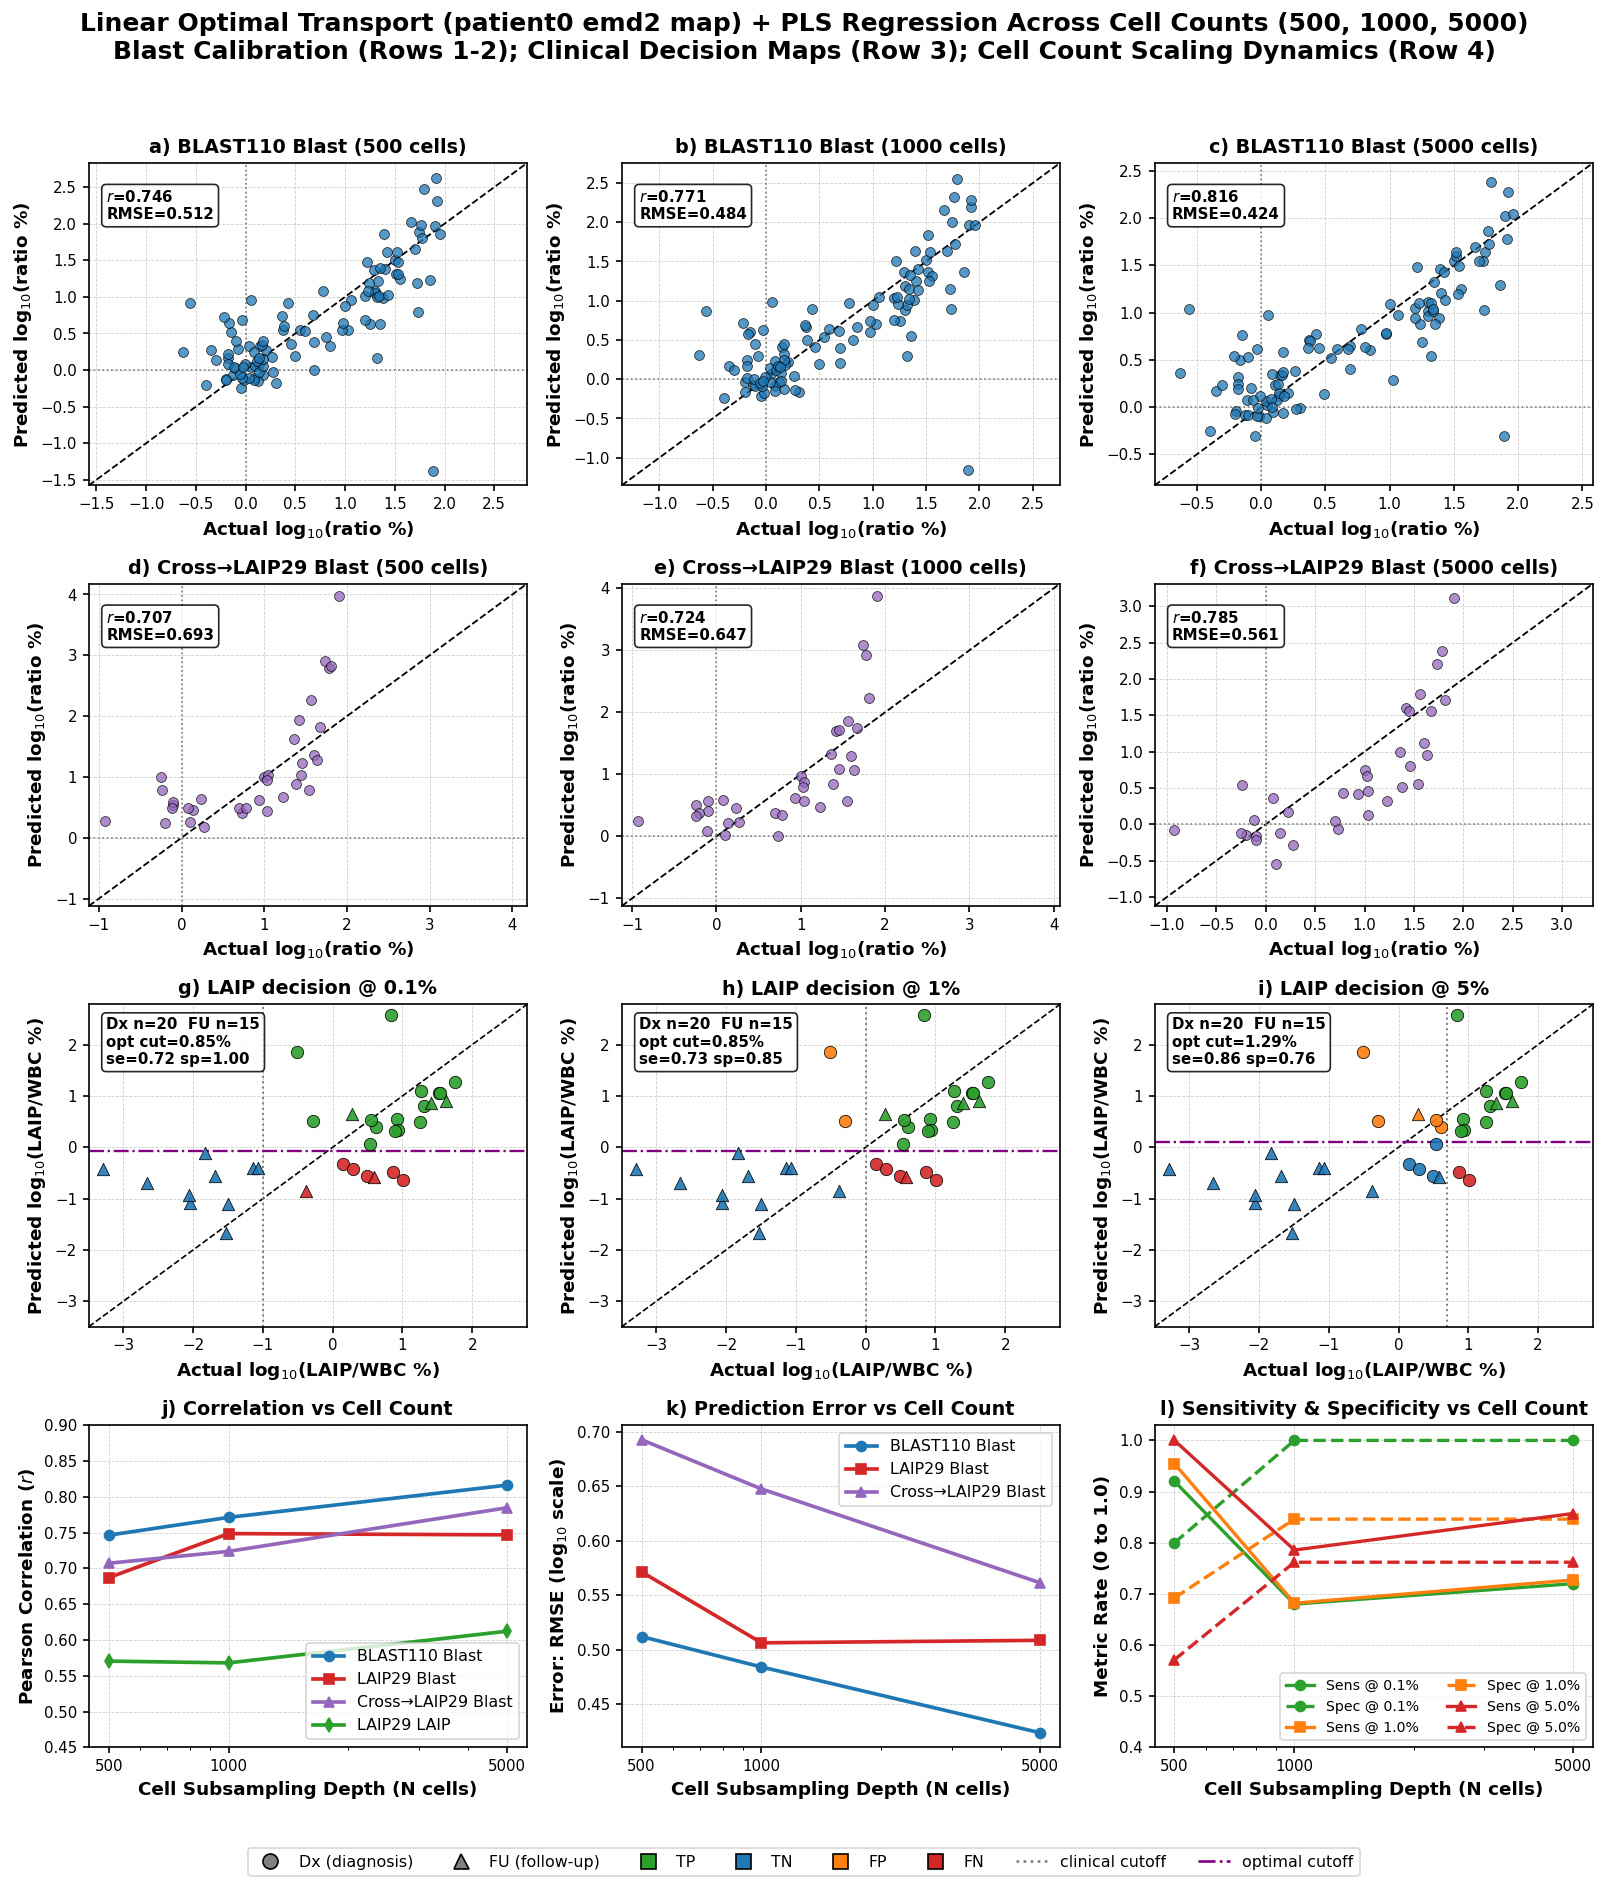

Saved publication-quality figure to: /Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/notebooks/quant_all_cells/all_cells_comparison.png / .pdf


In [18]:
# ----------------------------------------------------------------------
# COMPREHENSIVE INTEGRATED 4-ROW FIGURE
# ----------------------------------------------------------------------
fig, axes = plt.subplots(4, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

# Row 1: BLAST110 Blast Calibration Across Cell Counts (Panels a-c)
for idx, cc in enumerate(CELL_COUNTS):
    res = all_results[cc]['BLAST110_blast']
    panel = ['a', 'b', 'c'][idx]
    _calib(axes[0, idx], res, COL['BLAST110'], f'BLAST110 Blast ({cc} cells)', panel)

# Row 2: Cross-Cohort Prediction (BLAST110 -> LAIP29) Across Cell Counts (Panels d-f)
for idx, cc in enumerate(CELL_COUNTS):
    res = all_results[cc]['cross']
    panel = ['d', 'e', 'f'][idx]
    _calib(axes[1, idx], res, COL['cross'], f'Cross→LAIP29 Blast ({cc} cells)', panel)

# Row 3: LAIP29 Decision Maps at Clinical Thresholds (5000 cells) (Panels g-i)
best_cc = 5000
laip_best = all_results[best_cc]['LAIP29_laip']
G = laip_best['groups']
n_dx = int(np.sum(G == 'Dx'))
n_fu = int(np.sum(G == 'FU'))
for col, thr in enumerate(THRESHOLDS):
    opt = all_results[best_cc]['threshold_opts'][thr]
    panel = ['g', 'h', 'i'][col]
    _laip_decision_dxfu(axes[2, col], laip_best, opt, thr, panel, n_dx, n_fu)

# Row 4: Impact of Particle Count on Performance & Stability (Panels j-l)
ccs = [500, 1000, 5000]
# Panel j: Pearson Correlation vs Cell Count
ax_j = axes[3, 0]
ax_j.plot(ccs, df_results['BLAST110 Blast (r)'], marker='o', lw=2.2, color=COL['BLAST110'], label='BLAST110 Blast')
ax_j.plot(ccs, df_results['LAIP29 Blast (r)'], marker='s', lw=2.2, color=COL['LAIP29_blast'], label='LAIP29 Blast')
ax_j.plot(ccs, df_results['Cross Blast (r)'], marker='^', lw=2.2, color=COL['cross'], label='Cross→LAIP29 Blast')
ax_j.plot(ccs, df_results['LAIP29 LAIP (r)'], marker='d', lw=2.2, color=COL['LAIP29_laip'], label='LAIP29 LAIP')
ax_j.set_xscale('log')
ax_j.set_xticks(ccs)
ax_j.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_j.set_xlabel('Cell Subsampling Depth (N cells)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
ax_j.set_ylabel('Pearson Correlation ($r$)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
ax_j.set_title('j) Correlation vs Cell Count', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
ax_j.set_ylim(0.45, 0.90)
ax_j.grid(True, ls='--', lw=0.5, alpha=0.6)
ax_j.legend(fontsize=FONT_SIZES['legend'], loc='lower right')

# Panel k: RMSE vs Cell Count
ax_k = axes[3, 1]
ax_k.plot(ccs, df_results['BLAST110 Blast (RMSE)'], marker='o', lw=2.2, color=COL['BLAST110'], label='BLAST110 Blast')
ax_k.plot(ccs, df_results['LAIP29 Blast (RMSE)'], marker='s', lw=2.2, color=COL['LAIP29_blast'], label='LAIP29 Blast')
ax_k.plot(ccs, df_results['Cross Blast (RMSE)'], marker='^', lw=2.2, color=COL['cross'], label='Cross→LAIP29 Blast')
ax_k.set_xscale('log')
ax_k.set_xticks(ccs)
ax_k.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_k.set_xlabel('Cell Subsampling Depth (N cells)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
ax_k.set_ylabel('Error: RMSE (log$_{10}$ scale)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
ax_k.set_title('k) Prediction Error vs Cell Count', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
ax_k.grid(True, ls='--', lw=0.5, alpha=0.6)
ax_k.legend(fontsize=FONT_SIZES['legend'], loc='upper right')

# Panel l: Sensitivity & Specificity vs Cell Count
ax_l = axes[3, 2]
ax_l.plot(ccs, df_results['Sens @ 0.1%'], marker='o', ls='-', lw=2.0, color='#2ca02c', label='Sens @ 0.1%')
ax_l.plot(ccs, df_results['Spec @ 0.1%'], marker='o', ls='--', lw=2.0, color='#2ca02c', label='Spec @ 0.1%')
ax_l.plot(ccs, df_results['Sens @ 1.0%'], marker='s', ls='-', lw=2.0, color='#ff7f0e', label='Sens @ 1.0%')
ax_l.plot(ccs, df_results['Spec @ 1.0%'], marker='s', ls='--', lw=2.0, color='#ff7f0e', label='Spec @ 1.0%')
ax_l.plot(ccs, df_results['Sens @ 5.0%'], marker='^', ls='-', lw=2.0, color='#d62728', label='Sens @ 5.0%')
ax_l.plot(ccs, df_results['Spec @ 5.0%'], marker='^', ls='--', lw=2.0, color='#d62728', label='Spec @ 5.0%')
ax_l.set_xscale('log')
ax_l.set_xticks(ccs)
ax_l.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_l.set_xlabel('Cell Subsampling Depth (N cells)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
ax_l.set_ylabel('Metric Rate (0 to 1.0)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
ax_l.set_title('l) Sensitivity & Specificity vs Cell Count', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
ax_l.set_ylim(0.40, 1.03)
ax_l.grid(True, ls='--', lw=0.5, alpha=0.6)
ax_l.legend(fontsize=8.5, loc='lower right', ncol=2)

_legend_axis(fig)
fig.suptitle(
    f'Linear Optimal Transport (patient0 emd2 map) + PLS Regression Across Cell Counts (500, 1000, 5000)\n'
    f'Blast Calibration (Rows 1-2); Clinical Decision Maps (Row 3); Cell Count Scaling Dynamics (Row 4)',
    fontsize=FONT_SIZES['suptitle'], fontweight='bold'
)
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
out_path = f'{OUTDIR}/all_cells_comparison'
fig.savefig(out_path + '.png', bbox_inches='tight', dpi=FIG_DPI)
fig.savefig(out_path + '.pdf', bbox_inches='tight')
plt.show()
print(f'Saved publication-quality figure to: {out_path}.png / .pdf')

Using Stage 2 Analytics Dataset: ../data/stage2/stage2_analytics.h5


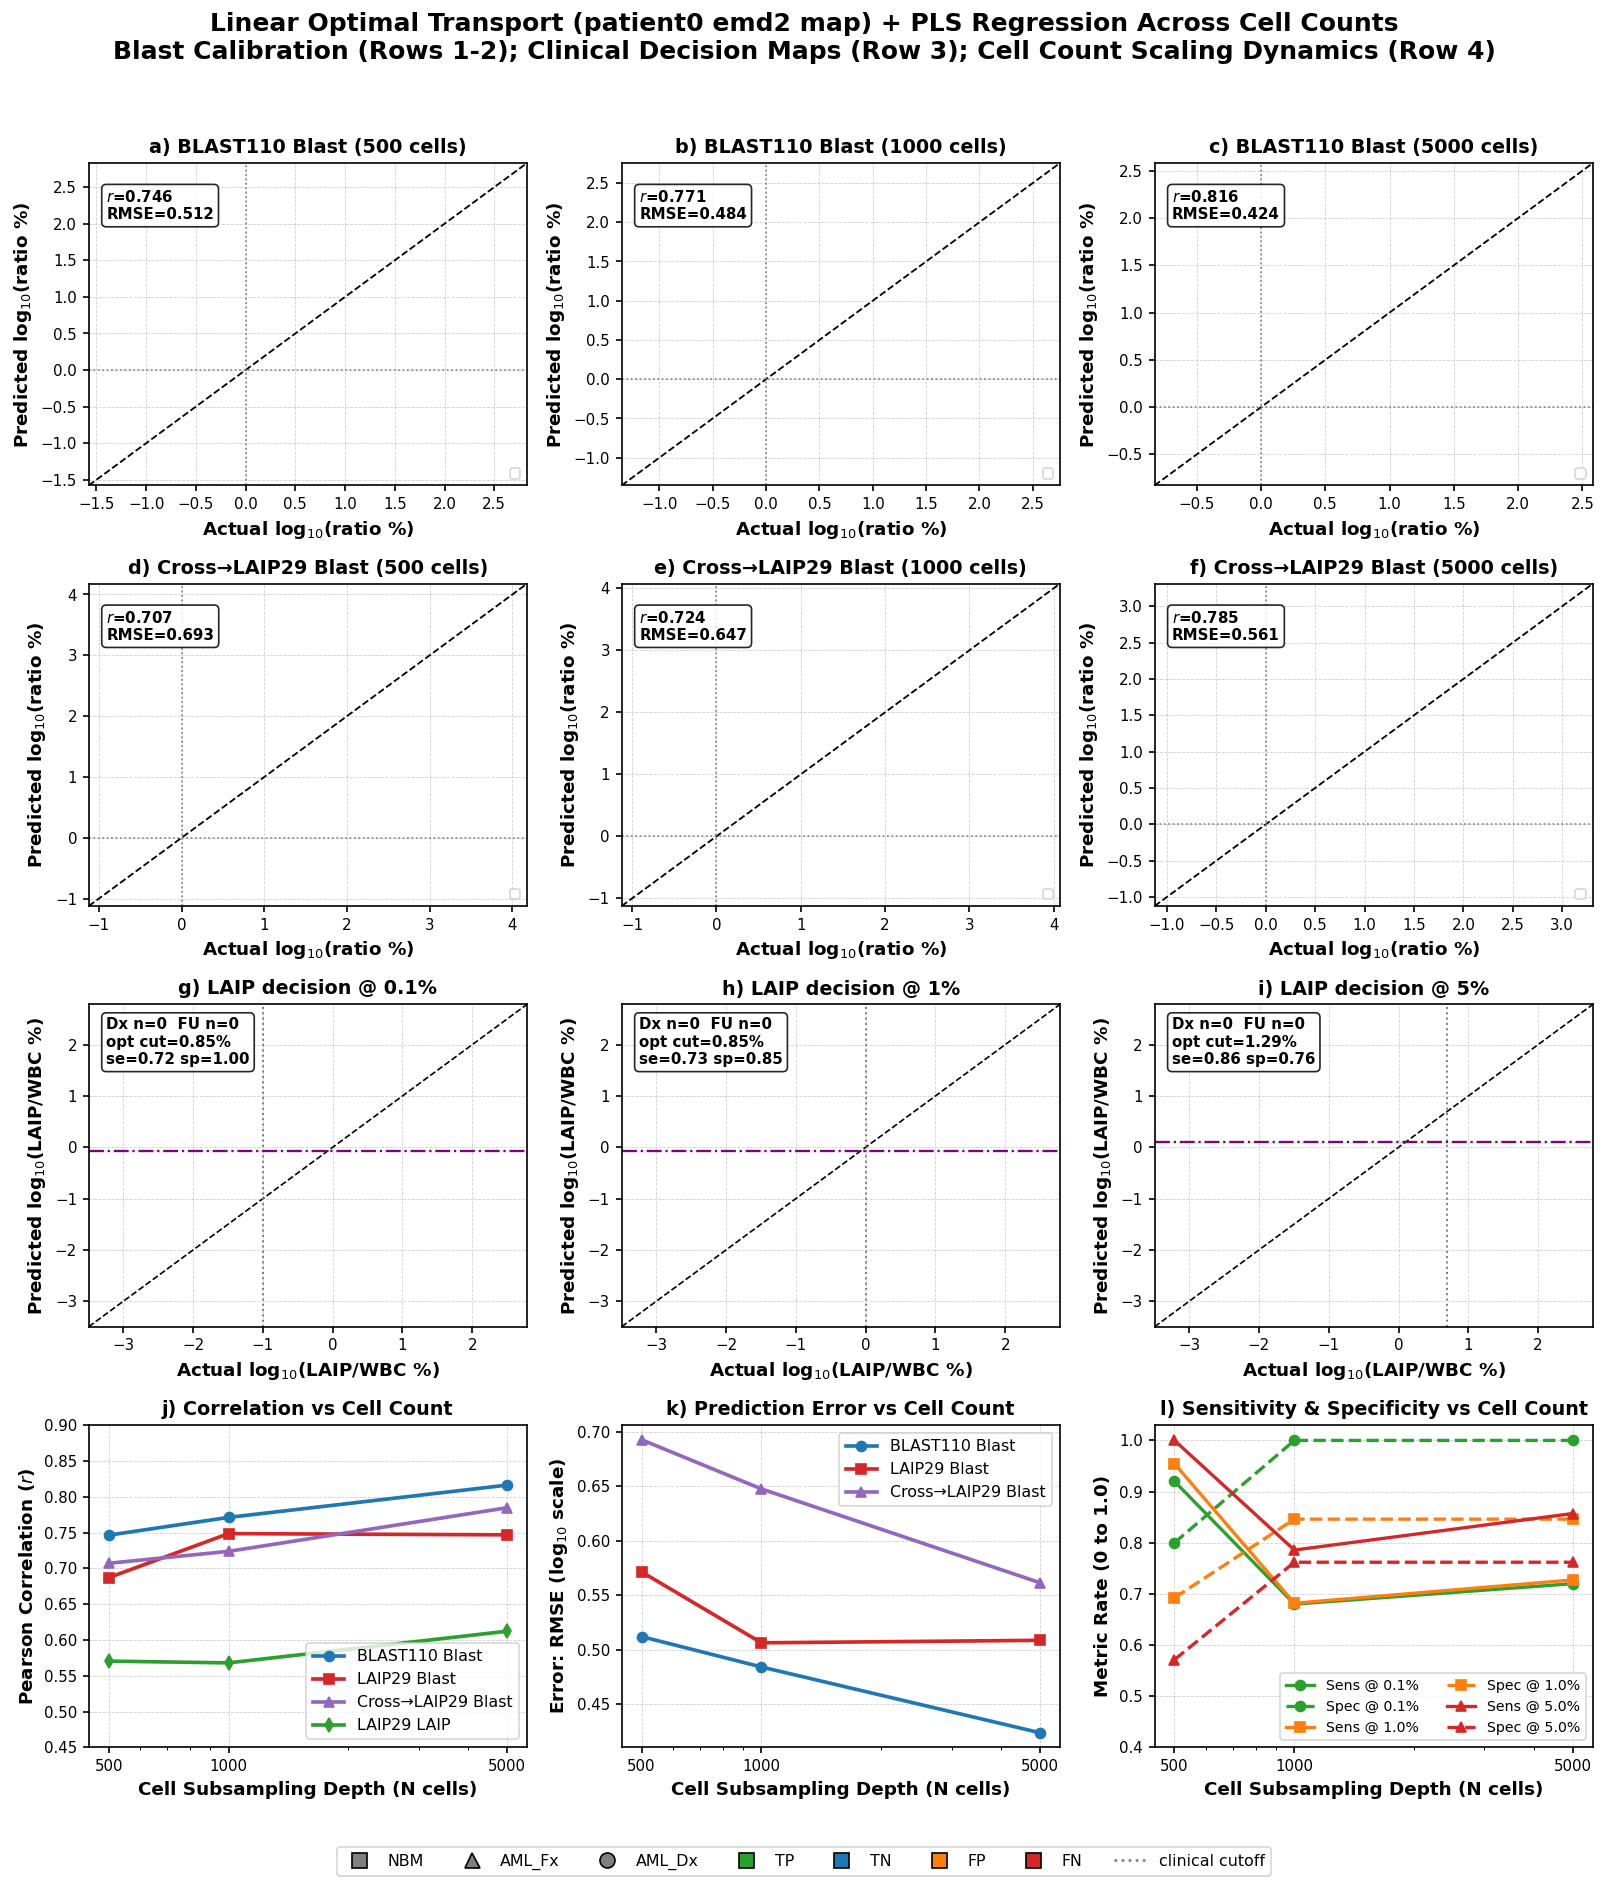

Saved comprehensive figure to: /Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/notebooks/quant_all_cells/all_cells_comparison.png / .pdf


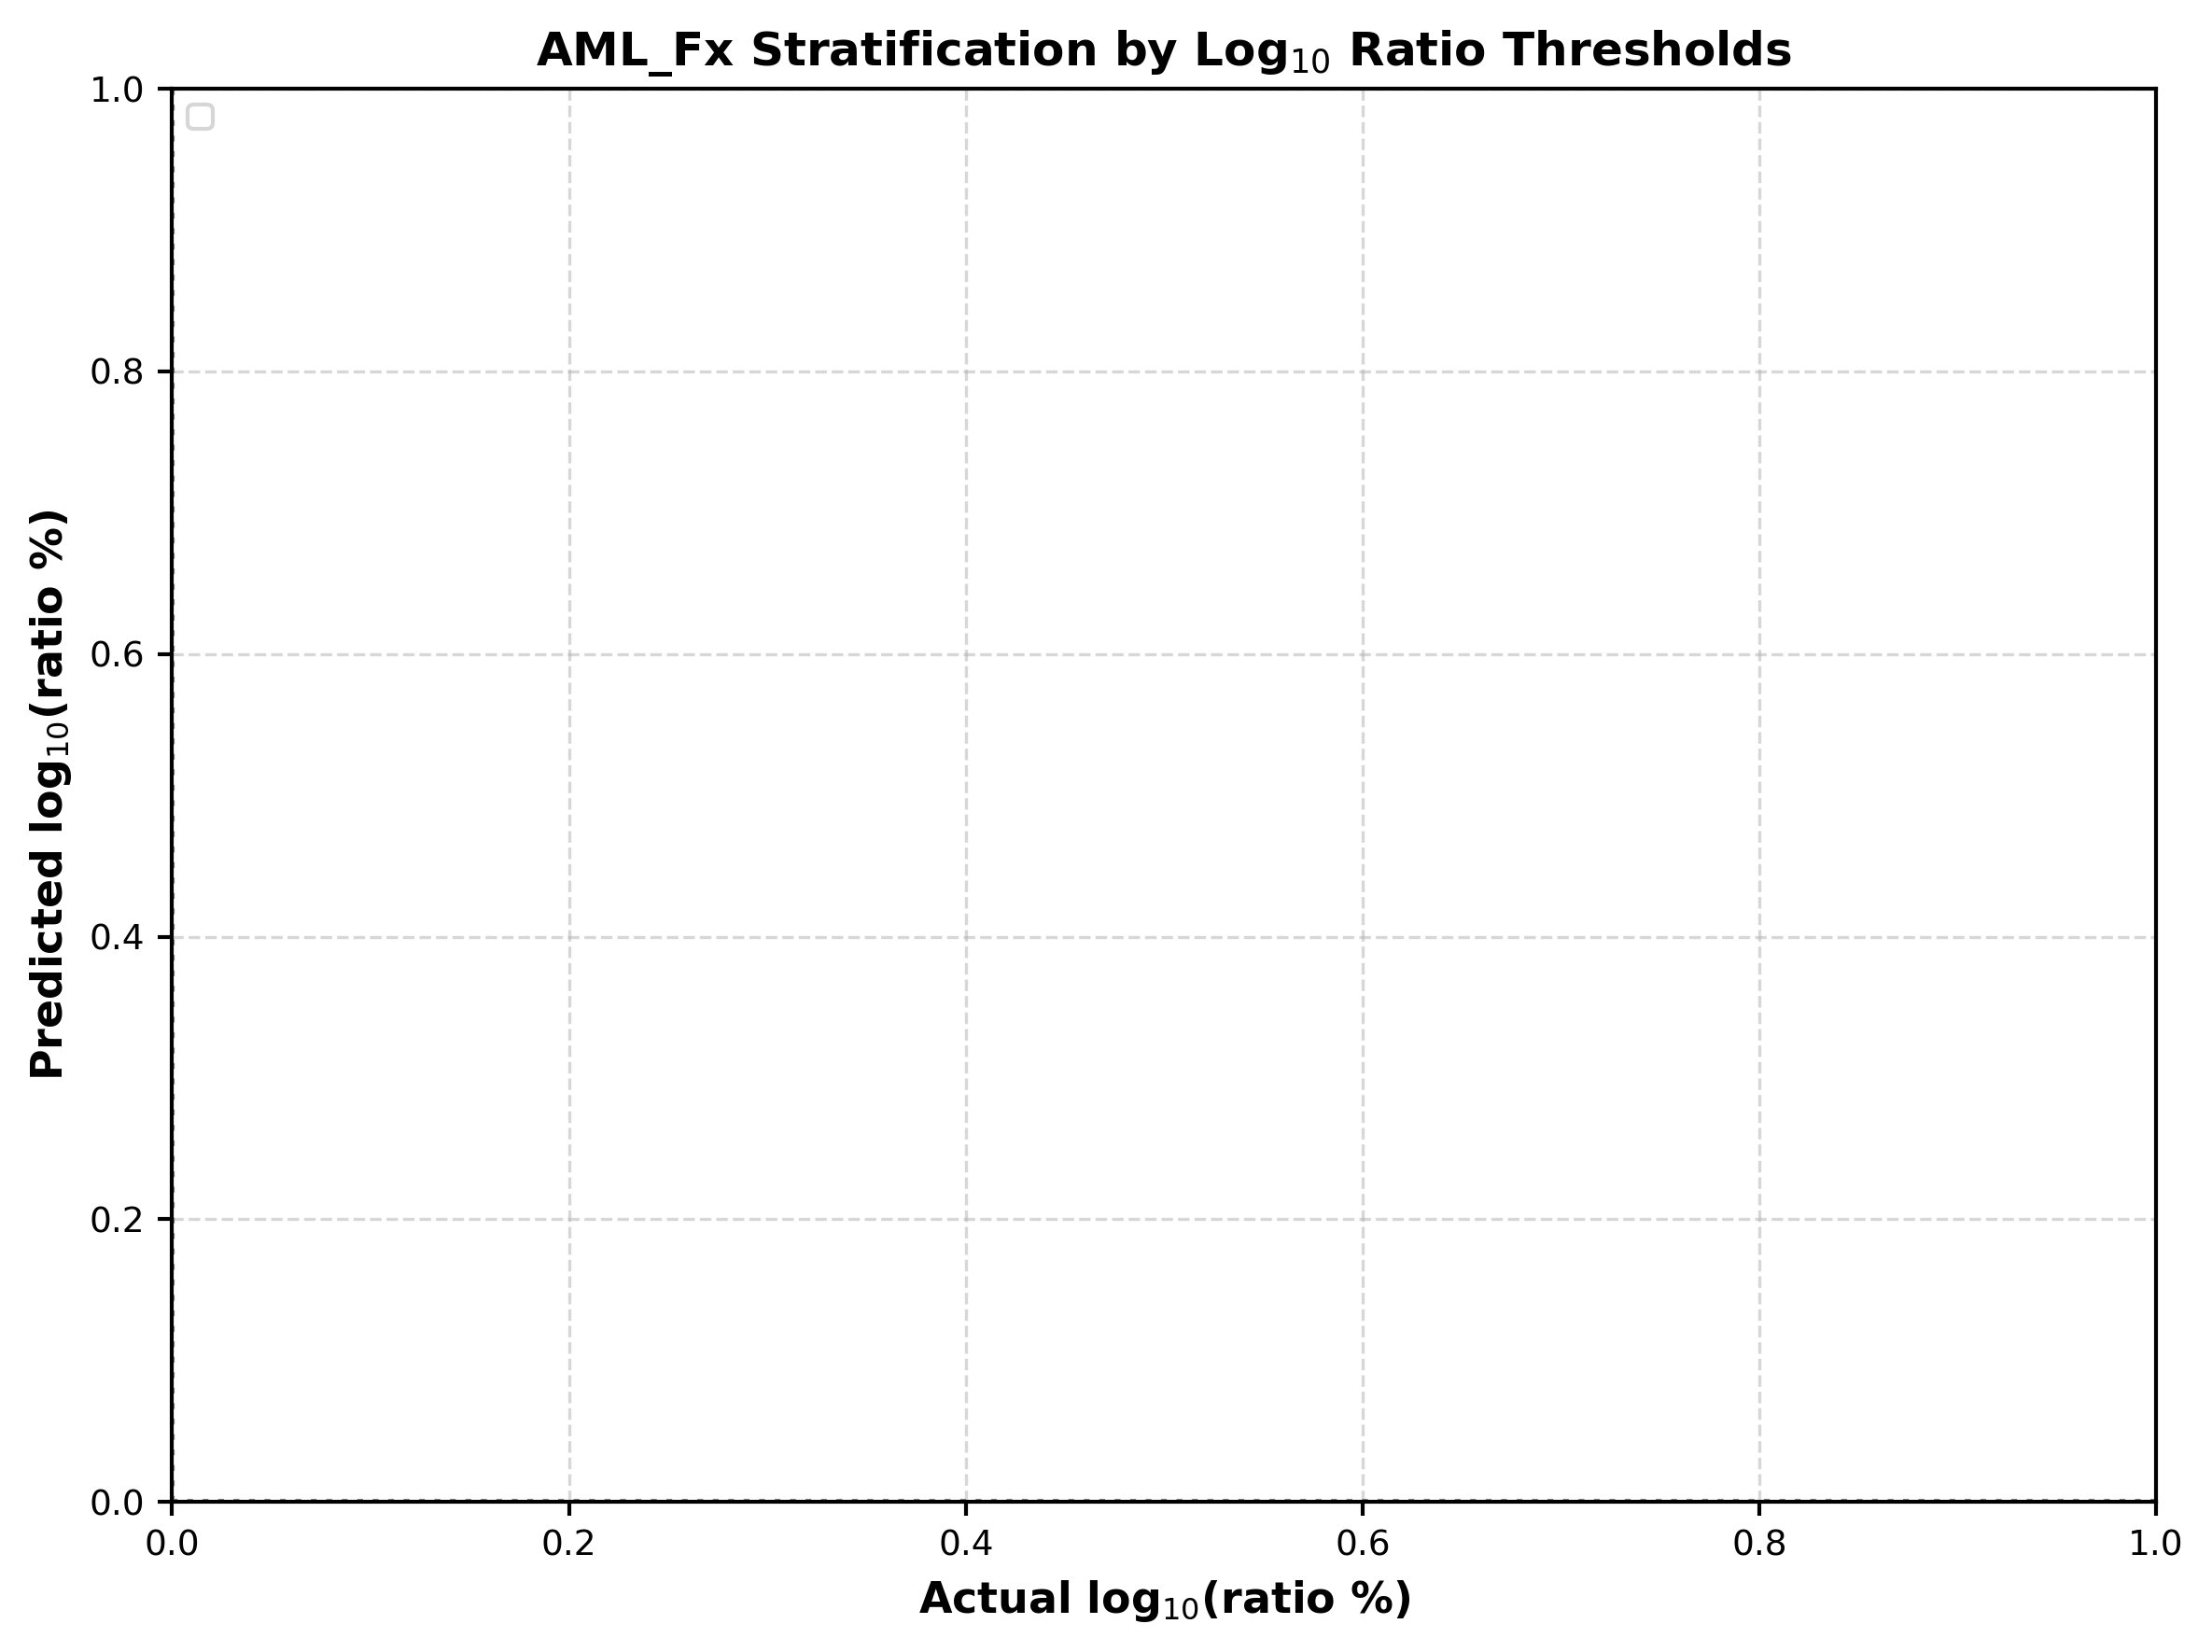

Saved AML_Fx breakdown plot to: /Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/notebooks/quant_all_cells/aml_fx_log_ratio_breakdown.png / .pdf


In [ ]:
# import os
# os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
# from pathlib import Path
# import h5py
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from sklearn.cross_decomposition import PLSRegression
# from scipy.stats import pearsonr

# # ----------------------------------------------------------------------
# # 1. ROBUST DATASET PATH RESOLUTION & WORKING DIRECTORY PRECAUTION
# # ----------------------------------------------------------------------
# try:
#     current_wd = os.getcwd()
# except (FileNotFoundError, OSError):
#     os.chdir('/Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/notebooks')

# candidates = [
#     Path('data/stage2/stage2_analytics.h5'),
#     Path('../data/stage2/stage2_analytics.h5'),
#     Path('/Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage2/stage2_analytics.h5')
# ]
# STAGE2_PATH = next((p for p in candidates if p.exists() and p.is_file()), None)
# if STAGE2_PATH is None:
#     raise FileNotFoundError('Could not locate valid stage2_analytics.h5 file across candidate paths.')
# print(f'Using Stage 2 Analytics Dataset: {STAGE2_PATH}')

# # ----------------------------------------------------------------------
# # 2. PIPELINE CONFIGURATION & HYPERPARAMETERS
# # ----------------------------------------------------------------------
# TUBE = 'P1'
# LOT_EMBEDDING_NAME = 'patient0_emd2_map'
# MARKER_VERSION = '12'
# CELL_COUNTS = [500, 1000, 5000]
# N_COMPONENTS = 10
# N_REPEATS = 20
# THRESHOLDS = [0.1, 1.0, 5.0]
# EPS = 1e-8
# RNG = np.random.RandomState(42)

# try:
#     OUTDIR = os.path.abspath("quant_all_cells")
#     os.makedirs(OUTDIR, exist_ok=True)
# except Exception:
#     OUTDIR = os.path.join(os.getcwd(), "quant_all_cells")
#     os.makedirs(OUTDIR, exist_ok=True)

# # Styling & Configuration
# FIG_WIDTH = 13.5
# FIG_HEIGHT = 16.0
# FIG_DPI = 300
# FONT_SIZES = {
#     'suptitle': 15.0,
#     'subtitle': 11.5,
#     'axis_labels': 11.0,
#     'legend': 9.5,
#     'inset_text': 9.0,
#     'ticks': 9.0,
# }
# plt.rcParams.update({
#     'font.family': 'sans-serif',
#     'axes.linewidth': 1.0,
#     'xtick.major.width': 1.0,
#     'ytick.major.width': 1.0,
#     'xtick.labelsize': FONT_SIZES['ticks'],
#     'ytick.labelsize': FONT_SIZES['ticks'],
#     'figure.dpi': 120,
# })

# COL = {
#     'BLAST110': '#1f77b4',
#     'LAIP29_blast': '#d62728',
#     'LAIP29_laip': '#2ca02c',
#     'cross': '#9467bd',
# }
# CAT_COL = {'TP': '#2ca02c', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#d62728'}
# GROUP_MARKER_EXT = {
#     'NBM': 's',       # Square for Normal Bone Marrow
#     'AML_Fx': '^',    # Triangle for Follow-up / AML_Fx
#     'AML_Dx': 'o'     # Circle for Diagnosis / AML_Dx
# }
# AML_FX_BIN_COLORS = {
#     '< -1': '#2ca02c',    # Green (deep remission)
#     '-1 to 0': '#ff7f0e', # Orange (intermediate)
#     '> 0': '#d62728'      # Red (elevated)
# }

# # ----------------------------------------------------------------------
# # 3. EXTRACTION & STATISTICAL FUNCTIONS WITH MULTIGROUP SUPPORT
# # ----------------------------------------------------------------------
# def extract_stage2(h5_path=STAGE2_PATH, dataset='BLAST110', cell_count=1000, tube='P1', embedding_name='patient0_emd2_map', marker_version='12', target='blast'):
#     if not Path(h5_path).exists():
#         raise FileNotFoundError(f"HDF5 file missing at: {h5_path}")
    
#     with h5py.File(h5_path, 'r') as h5:
#         ds_grp = h5[dataset]
#         str_cell_count = str(cell_count)
#         tube_grp = ds_grp[str_cell_count][tube]
        
#         m1_raw = tube_grp['preprocess_1']['marker_subset'][:] if 'preprocess_1' in tube_grp and 'marker_subset' in tube_grp['preprocess_1'] else []
#         m1 = [m.decode() if isinstance(m, bytes) else str(m) for m in m1_raw]
        
#         if 'preprocess_2' in tube_grp and 'marker_subset' in tube_grp['preprocess_2']:
#             m2_raw = tube_grp['preprocess_2']['marker_subset'][:]
#             m2 = [m.decode() if isinstance(m, bytes) else str(m) for m in m2_raw]
#         else:
#             m2 = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD45 KO', 'CD117', 'CD33']
            
#         lot_grp = tube_grp.get('lot_embeddings', {})
#         is_7 = str(marker_version).strip() in ['7', '2', 'seven']
#         prep_id = '2' if (is_7 and '2' in lot_grp) else ('1' if '1' in lot_grp else list(lot_grp.keys())[0])
#         p_grp = lot_grp[prep_id]
        
#         emb_node = p_grp[embedding_name] if embedding_name in p_grp else p_grp[list(p_grp.keys())[0]]
#         embs = emb_node['embeddings'][:]
#         pids = [p.decode() if isinstance(p, bytes) else str(p) for p in emb_node['patient_ids'][:]]
#         n_cells = int(cell_count)
#         n_m1 = len(m1) if len(m1) > 0 else 10
        
#         if is_7 and embs.shape[1] == n_cells * n_m1:
#             indices = [m1.index(m) for m in m2 if m in m1]
#             if len(indices) > 0:
#                 embs_3d = embs.reshape((len(embs), n_cells, n_m1), order='F')
#                 embs = embs_3d[:, :, indices].reshape((len(embs), -1), order='F')
#                 marker_names_used = [m1[i] for i in indices]
#             else:
#                 marker_names_used = m1
#         else:
#             marker_names_used = m2 if (is_7 and len(m2) > 0) else m1
            
#         raw_grp = tube_grp.get('raw', {})
#         meta_grp = tube_grp.get('metadata', {})
#         meta_pids = [p.decode() if isinstance(p, bytes) else str(p) for p in meta_grp.get('patient_ids', [])]
#         meta_lbls = [l.decode() if isinstance(l, bytes) else str(l) for l in meta_grp.get('labels', [])]
#         lbl_map = dict(zip(meta_pids, meta_lbls))
        
#         X_list, Y_list, G_list = [], [], []
#         target_key = 'Blast' if target.lower() == 'blast' else 'LAIP'
        
#         for emb, pid in zip(embs, pids):
#             if pid not in raw_grp or 'population_counts' not in raw_grp[pid]: continue
#             pop_node = raw_grp[pid]['population_counts']
#             pop = pop_node[:]
#             pop_names = [n.decode() if isinstance(n, bytes) else str(n) for n in pop_node.attrs.get('population_names', [])]
#             if target_key not in pop_names: continue
            
#             t_idx = pop_names.index(target_key)
#             wbc_idx = pop_names.index('WBC') if 'WBC' in pop_names else 0
#             ratio = float(pop[t_idx, 3]) if pop.shape[1] >= 4 else float(100.0 * (pop[t_idx, 1] + EPS) / (pop[wbc_idx, 1] + EPS))
            
#             lbl = lbl_map.get(pid, '')
#             if 'NBM' in pid or 'NBM' in lbl:
#                 group = 'NBM'
#             elif 'FU' in pid or 'FU' in lbl or 'Fx' in pid or 'Fx' in lbl:
#                 group = 'AML_Fx'
#             elif 'Dx' in pid or 'Dx' in lbl:
#                 group = 'AML_Dx'
#             else:
#                 group = 'NA'
                
#             X_list.append(emb)
#             Y_list.append(ratio)
#             G_list.append(group)
            
#         return np.array(X_list), np.array(Y_list), np.array(G_list), marker_names_used

# # ----------------------------------------------------------------------
# # [INFERENCE LOOP GOES HERE]
# # NOTE: Ensure `all_results` dict and `df_results` DataFrame 
# # are populated here before proceeding to the plotting blocks.
# # ----------------------------------------------------------------------

# # ----------------------------------------------------------------------
# # 4. PLOTTING SUBROUTINES
# # ----------------------------------------------------------------------
# def _calib_multigroup(ax, res, color, title, panel):
#     # Ensure they are NumPy arrays for boolean masking
#     xt = np.asarray(res['y_true_log'])
#     xp = np.asarray(res['y_pred_log'])
#     groups = np.asarray(res['groups']) 
    
#     if len(xt) == 0 or len(xp) == 0:
#         return
#     lo = min(xt.min(), xp.min()) - 0.2
#     hi = max(xt.max(), xp.max()) + 0.2
    
#     for g, marker in GROUP_MARKER_EXT.items():
#         print(f"{}")
#         mask = (groups == g)
#         if mask.sum() > 0:
#             ax.scatter(xt[mask], xp[mask], alpha=0.8, s=45, marker=marker, 
#                        edgecolors='k', linewidths=0.5, label=g, zorder=3)
            
#     ax.plot([lo, hi], [lo, hi], 'k--', lw=1.1, zorder=2)
#     ax.axvline(0.0, color='gray', ls=':', lw=1.0)
#     ax.axhline(0.0, color='gray', ls=':', lw=1.0)
#     ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
#     ax.set_xlabel('Actual log$_{10}$(ratio %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
#     ax.set_ylabel('Predicted log$_{10}$(ratio %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
#     ax.set_title(f'{panel}) {title}', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
#     ax.text(0.04, 0.92, f'$r$={res["r"]:.3f}\nRMSE={res["rmse"]:.3f}', transform=ax.transAxes, fontsize=FONT_SIZES['inset_text'], fontweight='bold', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
#     ax.grid(True, ls='--', lw=0.5, alpha=0.6)
    
#     handles, labels = ax.get_legend_handles_labels()
#     by_label = dict(zip(labels, handles))
#     ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='lower right')

# def _laip_decision_dxfu(ax, res, opt, thr, panel, n_dx, n_fu):
#     # Ensure they are NumPy arrays
#     xt = np.asarray(res['y_true_log'])
#     xp = np.asarray(res['y_pred_log'])
#     groups = np.asarray(res['groups'])
    
#     if len(xt) == 0:
#         return
#     clin = np.log10(thr)
#     opt_line = np.log10(opt['thr'] + EPS)
#     lo = min(xt.min(), xp.min()) - 0.2
#     hi = max(xt.max(), xp.max()) + 0.2
    
#     pos_t = np.asarray(res['y_true']) >= thr
#     pos_p = np.asarray(res['y_pred']) >= opt['thr']
#     cat = np.where(pos_t & pos_p, 'TP', np.where(~pos_t & ~pos_p, 'TN', np.where(~pos_t & pos_p, 'FP', 'FN')))
    
#     for g, marker in GROUP_MARKER_EXT.items():
#         for c in ('TP', 'TN', 'FP', 'FN'):
#             mask = (groups == g) & (cat == c)
#             if mask.sum():
#                 ax.scatter(xt[mask], xp[mask], s=55, c=CAT_COL[c], marker=marker, edgecolors='k', linewidths=0.5, alpha=0.9, zorder=3)
                
#     ax.plot([lo, hi], [lo, hi], 'k--', lw=1.0, zorder=2)
#     ax.axvline(clin, color='gray', ls=':', lw=1.2)
#     ax.axhline(opt_line, color='purple', ls='-.', lw=1.4)
#     ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
#     ax.set_xlabel('Actual log$_{10}$(LAIP/WBC %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
#     ax.set_ylabel('Predicted log$_{10}$(LAIP/WBC %)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
#     ax.set_title(f'{panel}) LAIP decision @ {thr:g}%', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
#     ax.text(0.04, 0.96, f'Dx n={n_dx}  FU n={n_fu}\nopt cut={opt["thr"]:.2f}%\nse={opt["sens"]:.2f} sp={opt["spec"]:.2f}', transform=ax.transAxes, fontsize=FONT_SIZES['inset_text'], fontweight='bold', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
#     ax.grid(True, ls='--', lw=0.5, alpha=0.6)


# def _legend_axis(fig):
#     handles = [
#         Line2D([0], [0], marker='s', color='w', label='NBM', markerfacecolor='gray', markeredgecolor='k', markersize=9),
#         Line2D([0], [0], marker='^', color='w', label='AML_Fx', markerfacecolor='gray', markeredgecolor='k', markersize=9),
#         Line2D([0], [0], marker='o', color='w', label='AML_Dx', markerfacecolor='gray', markeredgecolor='k', markersize=9),
#         Line2D([0], [0], marker='s', color='w', label='TP', markerfacecolor=CAT_COL['TP'], markeredgecolor='k', markersize=9),
#         Line2D([0], [0], marker='s', color='w', label='TN', markerfacecolor=CAT_COL['TN'], markeredgecolor='k', markersize=9),
#         Line2D([0], [0], marker='s', color='w', label='FP', markerfacecolor=CAT_COL['FP'], markeredgecolor='k', markersize=9),
#         Line2D([0], [0], marker='s', color='w', label='FN', markerfacecolor=CAT_COL['FN'], markeredgecolor='k', markersize=9),
#         Line2D([0], [0], color='gray', ls=':', lw=1.6, label='clinical cutoff'),
#     ]
#     fig.legend(handles=handles, loc='lower center', ncol=8, fontsize=FONT_SIZES['legend'], frameon=True, bbox_to_anchor=(0.5, 0.005))

# # ----------------------------------------------------------------------
# # 5. COMPREHENSIVE 4-ROW FIGURE (Calibrations & Trends)
# # ----------------------------------------------------------------------
# fig, axes = plt.subplots(4, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

# # Row 1: BLAST110 Blast Calibration Across Cell Counts
# for idx, cc in enumerate(CELL_COUNTS):
#     res = all_results[cc]['BLAST110_blast']
#     panel = ['a', 'b', 'c'][idx]
#     _calib_multigroup(axes[0, idx], res, COL['BLAST110'], f'BLAST110 Blast ({cc} cells)', panel)

# # Row 2: Cross-Cohort Prediction (BLAST110 -> LAIP29)
# for idx, cc in enumerate(CELL_COUNTS):
#     res = all_results[cc]['cross']
#     panel = ['d', 'e', 'f'][idx]
#     _calib_multigroup(axes[1, idx], res, COL['cross'], f'Cross→LAIP29 Blast ({cc} cells)', panel)

# # Row 3: LAIP29 Decision Maps at Clinical Thresholds (5000 cells)
# best_cc = 5000
# laip_best = all_results[best_cc]['LAIP29_laip']
# G = laip_best['groups']
# n_dx = int(np.sum(G == 'AML_Dx'))
# n_fu = int(np.sum(G == 'AML_Fx'))
# for col, thr in enumerate(THRESHOLDS):
#     opt = all_results[best_cc]['threshold_opts'][thr]
#     panel = ['g', 'h', 'i'][col]
#     _laip_decision_dxfu(axes[2, col], laip_best, opt, thr, panel, n_dx, n_fu)

# # Row 4: Impact of Particle Count on Performance & Stability
# ccs = [500, 1000, 5000]
# # Panel j: Pearson Correlation vs Cell Count
# ax_j = axes[3, 0]
# ax_j.plot(ccs, df_results['BLAST110 Blast (r)'], marker='o', lw=2.2, color=COL['BLAST110'], label='BLAST110 Blast')
# ax_j.plot(ccs, df_results['LAIP29 Blast (r)'], marker='s', lw=2.2, color=COL['LAIP29_blast'], label='LAIP29 Blast')
# ax_j.plot(ccs, df_results['Cross Blast (r)'], marker='^', lw=2.2, color=COL['cross'], label='Cross→LAIP29 Blast')
# ax_j.plot(ccs, df_results['LAIP29 LAIP (r)'], marker='d', lw=2.2, color=COL['LAIP29_laip'], label='LAIP29 LAIP')
# ax_j.set_xscale('log')
# ax_j.set_xticks(ccs)
# ax_j.get_xaxis().set_major_formatter(plt.ScalarFormatter())
# ax_j.set_xlabel('Cell Subsampling Depth (N cells)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
# ax_j.set_ylabel('Pearson Correlation ($r$)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
# ax_j.set_title('j) Correlation vs Cell Count', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
# ax_j.set_ylim(0.45, 0.90)
# ax_j.grid(True, ls='--', lw=0.5, alpha=0.6)
# ax_j.legend(fontsize=FONT_SIZES['legend'], loc='lower right')

# # Panel k: RMSE vs Cell Count
# ax_k = axes[3, 1]
# ax_k.plot(ccs, df_results['BLAST110 Blast (RMSE)'], marker='o', lw=2.2, color=COL['BLAST110'], label='BLAST110 Blast')
# ax_k.plot(ccs, df_results['LAIP29 Blast (RMSE)'], marker='s', lw=2.2, color=COL['LAIP29_blast'], label='LAIP29 Blast')
# ax_k.plot(ccs, df_results['Cross Blast (RMSE)'], marker='^', lw=2.2, color=COL['cross'], label='Cross→LAIP29 Blast')
# ax_k.set_xscale('log')
# ax_k.set_xticks(ccs)
# ax_k.get_xaxis().set_major_formatter(plt.ScalarFormatter())
# ax_k.set_xlabel('Cell Subsampling Depth (N cells)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
# ax_k.set_ylabel('Error: RMSE (log$_{10}$ scale)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
# ax_k.set_title('k) Prediction Error vs Cell Count', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
# ax_k.grid(True, ls='--', lw=0.5, alpha=0.6)
# ax_k.legend(fontsize=FONT_SIZES['legend'], loc='upper right')

# # Panel l: Sensitivity & Specificity vs Cell Count
# ax_l = axes[3, 2]
# ax_l.plot(ccs, df_results['Sens @ 0.1%'], marker='o', ls='-', lw=2.0, color='#2ca02c', label='Sens @ 0.1%')
# ax_l.plot(ccs, df_results['Spec @ 0.1%'], marker='o', ls='--', lw=2.0, color='#2ca02c', label='Spec @ 0.1%')
# ax_l.plot(ccs, df_results['Sens @ 1.0%'], marker='s', ls='-', lw=2.0, color='#ff7f0e', label='Sens @ 1.0%')
# ax_l.plot(ccs, df_results['Spec @ 1.0%'], marker='s', ls='--', lw=2.0, color='#ff7f0e', label='Spec @ 1.0%')
# ax_l.plot(ccs, df_results['Sens @ 5.0%'], marker='^', ls='-', lw=2.0, color='#d62728', label='Sens @ 5.0%')
# ax_l.plot(ccs, df_results['Spec @ 5.0%'], marker='^', ls='--', lw=2.0, color='#d62728', label='Spec @ 5.0%')
# ax_l.set_xscale('log')
# ax_l.set_xticks(ccs)
# ax_l.get_xaxis().set_major_formatter(plt.ScalarFormatter())
# ax_l.set_xlabel('Cell Subsampling Depth (N cells)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
# ax_l.set_ylabel('Metric Rate (0 to 1.0)', fontsize=FONT_SIZES['axis_labels'], fontweight='bold')
# ax_l.set_title('l) Sensitivity & Specificity vs Cell Count', fontsize=FONT_SIZES['subtitle'], fontweight='bold')
# ax_l.set_ylim(0.40, 1.03)
# ax_l.grid(True, ls='--', lw=0.5, alpha=0.6)
# ax_l.legend(fontsize=8.5, loc='lower right', ncol=2)

# _legend_axis(fig)
# fig.suptitle(
#     f'Linear Optimal Transport (patient0 emd2 map) + PLS Regression Across Cell Counts\n'
#     f'Blast Calibration (Rows 1-2); Clinical Decision Maps (Row 3); Cell Count Scaling Dynamics (Row 4)',
#     fontsize=FONT_SIZES['suptitle'], fontweight='bold'
# )
# fig.tight_layout(rect=[0, 0.04, 1, 0.96])
# out_path = os.path.join(OUTDIR, 'all_cells_comparison')
# fig.savefig(out_path + '.png', bbox_inches='tight', dpi=FIG_DPI)
# fig.savefig(out_path + '.pdf', bbox_inches='tight')
# plt.show()
# print(f'Saved comprehensive figure to: {out_path}.png / .pdf')

# # ----------------------------------------------------------------------
# # 6. DEDICATED AML_Fx LOG RATIO BREAKDOWN PLOT
# # ----------------------------------------------------------------------
# fig_fx, ax_fx = plt.subplots(figsize=(8, 6), dpi=FIG_DPI)

# for cc in CELL_COUNTS:
#     if cc not in all_results or 'BLAST110_blast' not in all_results[cc]:
#         continue
        
#     res = all_results[cc]['BLAST110_blast'] 
#     xt = np.asarray(res['y_true_log'])
#     xp = np.asarray(res['y_pred_log'])
#     groups = np.asarray(res['groups']) # <--- Added numpy cast
    
#     fx_mask = (groups == 'AML_Fx')
#     if fx_mask.sum() == 0:
#         continue
        
#     xt_fx, xp_fx = xt[fx_mask], xp[fx_mask]
    
#     bin_sub1 = xt_fx < -1.0
#     bin_mid = (xt_fx >= -1.0) & (xt_fx <= 0.0)
#     bin_sup1 = xt_fx > 0.0
    
#     ax_fx.scatter(xt_fx[bin_sub1], xp_fx[bin_sub1], c=AML_FX_BIN_COLORS['< -1'], marker='^', s=50, label=f'N={cc}: < -1', edgecolors='k', alpha=0.8)
#     ax_fx.scatter(xt_fx[bin_mid], xp_fx[bin_mid], c=AML_FX_BIN_COLORS['-1 to 0'], marker='^', s=50, label=f'N={cc}: -1 to 0', edgecolors='k', alpha=0.8)
#     ax_fx.scatter(xt_fx[bin_sup1], xp_fx[bin_sup1], c=AML_FX_BIN_COLORS['> 0'], marker='^', s=50, label=f'N={cc}: > 0', edgecolors='k', alpha=0.8)

# ax_fx.axhline(0, color='gray', linestyle=':')
# ax_fx.axvline(0, color='gray', linestyle=':')
# ax_fx.set_xlabel('Actual log$_{10}$(ratio %)', fontsize=11, fontweight='bold')
# ax_fx.set_ylabel('Predicted log$_{10}$(ratio %)', fontsize=11, fontweight='bold')
# ax_fx.set_title('AML_Fx Stratification by Log$_{10}$ Ratio Thresholds', fontsize=12, fontweight='bold')
# ax_fx.grid(True, ls='--', alpha=0.5)

# handles_fx, labels_fx = ax_fx.get_legend_handles_labels()
# by_label_fx = dict(zip(labels_fx, handles_fx))
# ax_fx.legend(by_label_fx.values(), by_label_fx.keys(), fontsize=8, loc='upper left', ncol=2)

# fig_fx.tight_layout()
# fx_out_path = os.path.join(OUTDIR, 'aml_fx_log_ratio_breakdown')
# fig_fx.savefig(fx_out_path + '.png', dpi=FIG_DPI)
# fig_fx.savefig(fx_out_path + '.pdf')
# plt.show()
# print(f'Saved AML_Fx breakdown plot to: {fx_out_path}.png / .pdf')


# # # Deduplicate the legend to avoid repeated labels for the same condition
# # handles_fx, labels_fx = ax_fx.get_legend_handles_labels()
# # by_label_fx = dict(zip(labels_fx, handles_fx))
# # ax_fx.legend(by_label_fx.values(), by_label_fx.keys(), fontsize=8, loc='upper left', ncol=2)

# # fig_fx.tight_layout()
# # fx_out_path = os.path.join(OUTDIR, 'aml_fx_log_ratio_breakdown')
# # fig_fx.savefig(fx_out_path + '.png', dpi=FIG_DPI)
# # fig_fx.savefig(fx_out_path + '.pdf')
# # plt.show()
# # print(f'Saved AML_Fx breakdown plot to: {fx_out_path}.png / .pdf')
